This notebook is used to show the use of p-values and the concept of p-hacking

In [ ]:
# ----------------------------
# Import packages
# ----------------------------
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

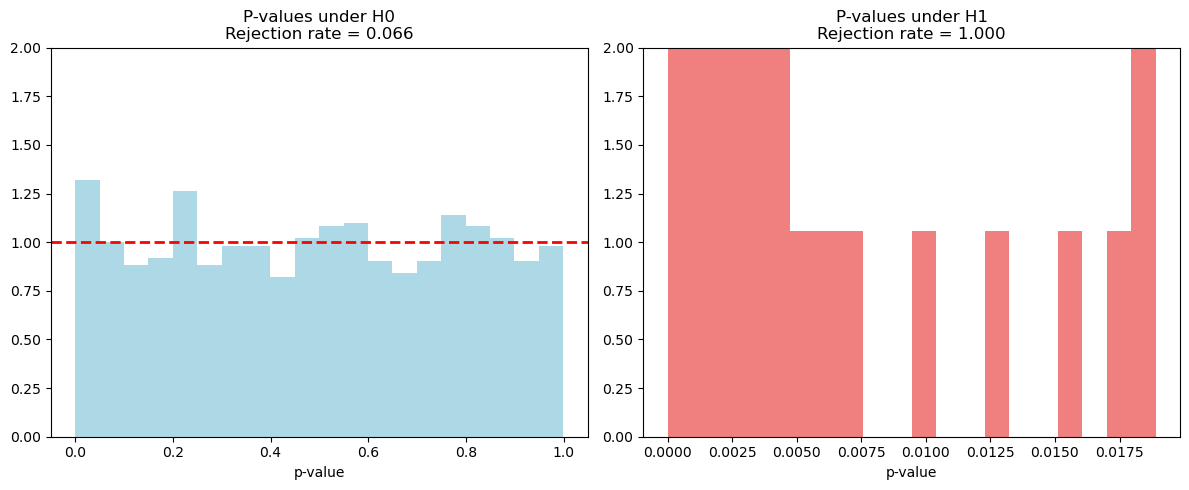

In [2]:
# ----------------------------
# Part 1: Histogram simulation
# ----------------------------
np.random.seed(123)

n = 1000
sample_size = 30

# Considering the simple hypothesis H0: mu = 0  vs H1: mu = 1;

# Generate p-values under H0
p_values_H0 = stats.ttest_1samp(np.random.normal(0, 1, (n, sample_size)), popmean=0, axis=1).pvalue


# Generate p-values under H1
p_values_H1 = stats.ttest_1samp(np.random.normal(1, 1, (n, sample_size)), popmean=0, axis=1).pvalue

# When we say generate under Hi we just sample under N(i,1) respectively  

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(p_values_H0, bins=20, density=True, color='lightblue')
axes[0].axhline(1, color='red', linestyle='--', linewidth=2)
axes[0].set_title("P-values under H0")
axes[0].set_xlabel("p-value")
axes[0].set_ylim(0, 2)
axes[0].set_title(f"P-values under H0\nRejection rate = {np.mean(np.array(p_values_H0)<0.05):.3f}")



axes[1].hist(p_values_H1, bins=20, density=True, color='lightcoral')
axes[1].set_title("P-values under H1")
axes[1].set_xlabel("p-value")
axes[1].set_ylim(0, 2)
axes[1].set_title(f"P-values under H1\nRejection rate = {np.mean(np.array(p_values_H1)<0.05):.3f}")


plt.tight_layout()
plt.show()





In [3]:
# -------------------------------------------
# Part 2: Sequential optional stopping test
# -------------------------------------------

np.random.seed(42)

def simulate_optional_stopping(mu=0, n_sim=1000, max_n=500, alpha=0.05):
    type1_errors = 0   # Optional stopping
    no_inflated = 0    # No p-hacking baseline

    for _ in range(n_sim):
        # Generate Data with corresponding mu
        data = np.random.normal(mu, 1, max_n)

        # No p-hacking baseline
        p_no_hack = stats.ttest_1samp(data, popmean=0).pvalue
        # Count the number of rejections we find
        if p_no_hack < alpha:
            no_inflated += 1

        # Optional stopping testing every 10 observations
        for n in range(10, max_n + 1, 10):
            p_val = stats.ttest_1samp(data[:n], popmean=0).pvalue
            if p_val < alpha:
                type1_errors += 1
                # If in the experiment we find evidence to reject the null, then it becomes interesting to publish!
                # This will introduce the publication bias
                break

    inflated_alpha = type1_errors / n_sim
    no_inflated_rate = no_inflated / n_sim

    print(f"Type I Error Rate (no p-hacking): {no_inflated_rate:.3f}")
    print(f"Inflated Type I Error Rate (optional stopping): {inflated_alpha:.3f}")

    return np.array([inflated_alpha, no_inflated_rate])


# Run once
simulate_optional_stopping()


Type I Error Rate (no p-hacking): 0.053
Inflated Type I Error Rate (optional stopping): 0.338


array([0.338, 0.053])

Type I Error Rate (no p-hacking): 0.994
Inflated Type I Error Rate (optional stopping): 0.998
Type I Error Rate (no p-hacking): 0.942
Inflated Type I Error Rate (optional stopping): 0.975
Type I Error Rate (no p-hacking): 0.703
Inflated Type I Error Rate (optional stopping): 0.842
Type I Error Rate (no p-hacking): 0.305
Inflated Type I Error Rate (optional stopping): 0.572
Type I Error Rate (no p-hacking): 0.074
Inflated Type I Error Rate (optional stopping): 0.356
Type I Error Rate (no p-hacking): 0.039
Inflated Type I Error Rate (optional stopping): 0.331
Type I Error Rate (no p-hacking): 0.073
Inflated Type I Error Rate (optional stopping): 0.343
Type I Error Rate (no p-hacking): 0.306
Inflated Type I Error Rate (optional stopping): 0.595
Type I Error Rate (no p-hacking): 0.721
Inflated Type I Error Rate (optional stopping): 0.843
Type I Error Rate (no p-hacking): 0.944
Inflated Type I Error Rate (optional stopping): 0.974
Type I Error Rate (no p-hacking): 0.993
Inflated Type I Erro

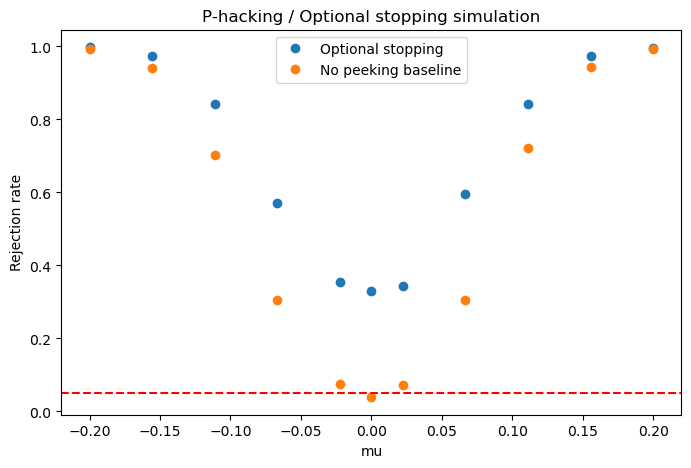

In [14]:
# ----------------------------
# Part 3: Run across mu values
# ----------------------------

x = np.linspace(-0.2, 0.2, 10)
x = np.sort(np.unique(np.concatenate([x, [0]]))) # zero to include the case considered before

results = np.array([simulate_optional_stopping(mu) for mu in x])

# ----------------------------
# Plot rejection rates
# ----------------------------

plt.figure(figsize=(8, 5))
plt.plot(x, results[:, 0], 'o', label="Optional stopping")
plt.plot(x, results[:, 1], 'o', label="No peeking baseline")

plt.axhline(0.05, color="red", linestyle="--")
plt.xlabel("mu")
plt.ylabel("Rejection rate")
plt.legend()
plt.title("P-hacking / Optional stopping simulation")
plt.show()